# Pandas Series — Complete Notes (Lec 20)

## Pandas Kya Hai?

Pandas ek fast, powerful, flexible aur easy-to-use open source data analysis tool hai, jo Python ke upar bana hai. Kisi bhi ML model ko banane se pehle data ko samajhna important hota hai, aur data samajhne ke liye humein Pandas chahiye hota hai.

Pandas **numpy** ke upar bana hai — jab tum pandas import karte ho to internally numpy bhi automatically import ho jaata hai apne use ke liye, lekin tum use directly access nahi kar sakte. Uske liye alag se `import numpy as np` karna padta hai.

## Pandas Ke Do Main Objects

Pandas mein mainly do objects hote hain jo sabse zyada use hote hain:

```mermaid
graph LR
    A[Pandas] --> B["Series (1D)"]
    A --> C["DataFrame (2D)"]
    B --> D["Ek table ka single column jaisa"]
    C --> E["Poori table — multiple columns (agla lecture)"]
```

## Series Kya Hai?

Pandas Series ek **1D array** hai jo kisi bhi type ka data hold kar sakta hai. Agar ek table hai, to uske ek column ko Series bol sakte ho.

Series ke andar do parts hote hain:

```mermaid
graph TD
    S["Pandas Series"] --> I["Index<br/>(default 0,1,2... ya custom labels)"]
    S --> V["Values<br/>(actual data — internally numpy array)"]
```

Example:
```python
country = ['India','Pakistan','USA','Nepal','Srilanka']
pd.Series(country)
```
Output:
```
0       India
1    Pakistan
2         USA
3       Nepal
4    Srilanka
dtype: object
```
Yahan 0,1,2,3,4 index hai, aur `dtype` batata hai ki andar ka data kis type ka hai.

## Series Banane Ke Tarike

```mermaid
flowchart TD
    A[Series Banane Ke Ways] --> B["List se<br/>pd.Series(list)"]
    A --> C["Custom index ke saath<br/>pd.Series(list, index=labels)"]
    A --> D["Naam ke saath<br/>pd.Series(list, name='...')"]
    A --> E["Dictionary se<br/>pd.Series(dict)<br/>keys → index, values → values"]
    A --> F["CSV se<br/>pd.read_csv(path).squeeze()"]
```

### 1. List se
```python
runs = [13,24,56,78,100]
runs_series = pd.Series(runs)
```

### 2. Custom Index ke saath
```python
marks = [67,57,89,100]
subjects = ['maths','english','science','hindi']
pd.Series(marks, index=subjects)
```
`index` parameter se decide karte ho ki kaunsi array meri index banegi.

### 3. Name Parameter
```python
marks = pd.Series(marks, index=subjects, name='Nitish ke marks')
```
`name` parameter se series ko ek naam mil jaata hai, jo print hone par dtype ke upar dikhta hai.

### 4. Dictionary se
```python
marks = {'maths':67, 'english':57, 'science':89, 'hindi':100}
marks_series = pd.Series(marks, name='nitish ke marks')
```
Dictionary key-value pairs store karti hai, isliye series bante time **keys index** ban jaati hain aur **values** series ki values ban jaati hain.

### 5. Real CSV Dataset se
```python
subs = pd.read_csv(fp2).squeeze()
kohli_runs = pd.read_csv(fp1, index_col="match_no").squeeze()
movies = pd.read_csv(fp3, index_col="movie").squeeze()
```
- `read_csv` normally ek **DataFrame** banata hai — use Series mein convert karne ke liye `.squeeze()` lagate hain (purane pandas versions mein `squeeze=True` parameter hota tha, ab remove ho chuka hai).
- `index_col` se batate ho ki kaunsa column index banega.
- Print karte waqt series **truncated** dikhti hai (upar-neeche ki 5-5 rows max) — lekin original file mein kuch truncate nahi hota, sirf display mein hota hai.

## Series Attributes

| Attribute | Kya Deta Hai |
|---|---|
| `.size` | Series ka total size |
| `.dtype` | Series ke data ka type |
| `.name` | Series ko diya gaya naam |
| `.is_unique` | Check karta hai ki values unique hain ya nahi |
| `.index` | Series ki saari indexes (start, end, increment) |
| `.values` | Saari values ek numpy array ke roop mein |

## Important Series Methods

| Method | Kaam |
|---|---|
| `.head(n)` | Shuru ki n rows ka preview (default 5) |
| `.tail(n)` | Aakhri n rows ka preview (default 5) |
| `.sample(n)` | Randomly n rows nikaalta hai — bias avoid karne ke liye useful (jaise agar data marks ke hisaab se sorted ho) |
| `.value_counts()` | Har unique value ki frequency deta hai, descending order mein |
| `.sort_values()` | Values ko ascending order mein sort karta hai (`ascending=False` se descending) |
| `.sort_index()` | Index ko sort karta hai — values nahi |

Dono sorting methods mein `ascending` aur `inplace` parameters hote hain. `inplace=True` set karne se original series pe **permanent** change ho jaata hai, aur function khud `None` return karta hai.

## Mathematical Functions

| Function | Kaam |
|---|---|
| `.count()` | Non-missing values ka count (`.size` missing values ko bhi count kar leta hai, `.count()` nahi) |
| `.sum()` | Saari values ka sum |
| `.prod()` | Saari values ka product |
| `.mean()` | Average |
| `.median()` | Median |
| `.mode()` | Sabse zyada repeat hone wali value |
| `.std()` | Standard deviation |
| `.var()` | Variance |
| `.max()` / `.min()` | Max / Min value |
| `.describe()` | Ek saath saari mathematical quantities ka summary |

## Indexing & Slicing

Yeh part thoda tricky hai, isliye dhyaan se:

```mermaid
flowchart TD
    A["Series Indexing"] --> B{"Custom string index hai?"}
    B -->|"Nahi, default numeric hai"| C["Direct indexing chalegi<br/>series[0]"]
    B -->|"Haan, custom hai"| D["series[0] ERROR dega<br/>kyunki index string type ka hai"]
    D --> E["iloc use karo<br/>series.iloc[0]<br/>(purani classical array jaisa, negative bhi chalega)"]
```

Key points:
- Positive normal indexing chalti hai, lekin **negative indexing nahi** chalti (jab tak custom label khud -1 na ho).
- Agar custom string index diya gaya hai (jaise `movies` series jisme movie naam index hai), to `movies[0]` error dega kyunki index ek string hai — isliye **`.iloc[]`** use karo, jo purani classical array ki tarah treat karta hai aur negative indexing bhi support karta hai.
- **Slicing** mein internal numeric indexing ka fayda still milta hai: `kohli_runs[5:17]` ya `movies[-5:]` (aakhri 5 movies) chal jaayega.
- **Fancy indexing** bhi supported hai: `kohli_runs[[1,3,5,8]]` ya `movies.iloc[[1,3,5,8]]` (string index ke case mein `.iloc` zaroori hai).
- **Label based indexing**: `movies["Hum Tumhare Hain Sanam"]`.

## Series Edit Karna

Series ki value change karne ke 3 tarike:
```python
marks_series.iloc[2] = 99          # position se
marks_series["science"] = 99       # label se
marks_series[1:2] = [99]           # slicing se
```
Agar diya gaya index pehle se exist nahi karta, to woh naya index + value series mein automatically **add** ho jaata hai (slicing ya fancy indexing dono se).

## Series + Python Built-in Functions

```python
len(subs)          # length
type(subs)          # Series ka type
dir(subs)           # saare available attributes/methods
sorted(subs)        # ascending sort, list return karta hai
min(subs), max(subs)
```

**Type conversion:**
```python
list(subs)     # list mein convert
dict(movies)   # dict mein convert
```

**Membership operator (`in`)** — yeh **index** pe kaam karta hai, chahe custom ho ya default:
```python
"2 States (2014 film)" in movies
```

## Looping

```python
for i in movies:              # default values pe loop
    print(i)

for i in movies.index:        # indexes pe loop
    print(i)

for i in movies.index:        # index se value nikaalna
    print(movies[i])
```

## Arithmetic & Relational Operators

Series pe direct arithmetic aur relational operations kaam karte hain (vectorized, sabhi elements pe ek saath apply hote hain):

```python
100 - marks_series      # har subject mein 100 aane ke liye kitne marks kam hain
kohli_runs > 50          # boolean series return karta hai (True/False)
```

## Boolean Indexing

Yeh concept bohot important hai. Pehle ek condition lagakar ek **boolean mask** series banti hai (True/False values ki), phir usko original series pe **filter** ki tarah laga dete hain.

```mermaid
flowchart LR
    A["Original Series<br/>kohli_runs"] --> B["Condition Apply<br/>kohli_runs >= 50"]
    B --> C["Boolean Mask Series<br/>(True / False values)"]
    C --> D["Original Series pe Mask Lagao<br/>kohli_runs[mask]"]
    D --> E["Filtered Series<br/>(sirf True wali rows)"]
```

```python
x = kohli_runs >= 50
print(kohli_runs[x])              # jitne matches mein 50+ runs bane
print(kohli_runs[kohli_runs==0])  # ducks (0 runs wale matches)

# 20+ movies karne wale actors
print(movies.value_counts()[movies.value_counts() >= 20])
```

## Plotting Graphs

Series direct `.plot()` support karti hai (matplotlib ke upar based hai):

```python
subs.plot()                                       # line plot (default)
movies.value_counts().plot()                      # line plot
movies.value_counts().head(20).plot(kind="bar")   # bar chart
movies.value_counts().head(20).plot(kind="pie")   # pie chart
movies.value_counts().head(20).plot(kind="area")  # area chart
```

```mermaid
graph LR
    A[".plot(kind=...)"] --> B["'line' (default)"]
    A --> C["'bar'"]
    A --> D["'pie'"]
    A --> E["'area'"]
```

---

## Quick Recap

```mermaid
flowchart TD
    A["Series Banao<br/>(list / dict / csv)"] --> B["Attributes Check Karo<br/>(size, dtype, index, values)"]
    B --> C["Methods Use Karo<br/>(head, tail, sort_values, value_counts)"]
    C --> D["Math Functions<br/>(mean, median, std, describe)"]
    D --> E["Indexing / Slicing<br/>(iloc vs label vs default)"]
    E --> F["Boolean Masking<br/>(filter conditions se)"]
    F --> G["Plot Karo<br/>(line, bar, pie, area)"]
```

**Series = 1D labeled array.** Agla lecture DataFrame pe hoga, jo basically multiple Series ka combination hota hai (poori table).

In [ ]:
#Pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python programming language.
 
#Kisi bhi model ko banane ke liye data samjhna is importatn and data ko samjhne ke liye we need pandas 
# https://pandas.pydata.org/about/index.html pandas documentation

In [ ]:
# Pandas main there are differne tobject jinnme se do sabse zyada use honge :series,dataframe is file mainn series hai 

#pandas series is like 1D array holdinng data of any type 
#and agar ek table hai to uske ek column ko ek series bol skte ho 

# A Pandas Series is like a column in a table

In [ ]:
#Importing pandas :-pandas numpy ke upar bana hai to when we import pandas it automatically imports numpy internally for its own use.

#   hai   hum nhi use kar skte humko use karna hai to humko  specifically import karna hoga 

In [ ]:
import numpy as np
import pandas as pd

#Creating pandas series from different python datatypes 
#from list 

country = ['India','Pakistan','USA','Nepal','Srilanka']

pd.Series(country) #pandas main Series karke ek class hai to hum uska use kar rhe hai 

# 0       India
# 1    Pakistan
# 2         USA
# 3       Nepal
# 4    Srilanka
# dtype: str

#ye object jo hai usme values to hai  hi par 0,1,2,3,4 bhi hai inko index bulate hai and end main dtype :str ye batata hai ki jo data andar hai uska type kya hai previous pandas versionns main isko object bol deta htha par new version main aisa shayad ho par max to max nhi hi hota 

In [ ]:
#Integrr type series through list 
#Batsman ke runs in diff matches 
runs = [13,24,56,78,100]
runs_series=pd.Series(runs)
print(runs_series)

In [ ]:
#creating custom indexes 
marks = [67,57,89,100]
subjects = ['maths','english','science','hindi']

#Iwant ki series ke index main subjects ho and marks ki series ho to index paramater se kounsi array meri index hogi ye  decide kar skta hoon 

pd.Series(marks,index=subjects)

In [ ]:
# setting a name for series object 
marks = pd.Series(marks,index=subjects,name='Nitish ke marks')
#ab jo ye name parameter hai na ye series ko Nitish ke marks karke naam de dega 
print(marks)
# maths       67
# english     57
# science     89
# hindi      100
# Name: Nitish ke marks, dtype: int64

In [ ]:
#Series from dictionary 
marks = {
    'maths':67,
    'english':57,
    'science':89,
    'hindi':100
}

marks_series = pd.Series(marks,name='nitish ke marks')
marks_series
#Isme kya hoga na ki since dictionary stores key value pairs to series bante time jo keys hogi that will be used as index while values ki series ban jayegi 

In [ ]:
#Series Attributes 
import pandas as pd 
marks = [67,57,89,100]
marks_series = pd.Series(marks,name='nitish ke marks')
marks_series.size#batayega ki marks_series ka size kitna hai 

marks_series.dtype #series ksi type ki bani hai batayega 

marks_series.name #series ko humne jo naam diya tha woh naam batayega 

marks_series.is_unique #batayega ki series ke andar ke items unique hai ki nhi 

marks_series.index #gives all the indexes of series start kisse horaha khatam kisse horaha agar increment hai to kitna hai 

marks_series.values #values saare numpy array main daalke wo numpy array return kar dega 

In [ ]:
#Creating series using real world data sets 
#series using read_csv
#read_csv is  a function which uses a csv file to create Series also ye ek excel type ki file hoti hai and also ye excel files comma seperated hoti hai matlab import karoge toh waise hi aayegi 

#Hum teen data sets ko import karenge and then in teeno ka use karke hum teen different series banyenge 

#https://drive.google.com/drive/folder... is  link se teen datasets download kar lena kohli.csv subs.csv and bollywood.csv then uske path copy karke ye karna 

fp1=r"C:\Users\Asus\Downloads\kohli_ipl.csv"
fp2=r"C:\Users\Asus\Downloads\subs.csv"
fp3=r"C:\Users\Asus\Downloads\bollywood.csv"

#subs.csv main peechle 365 days main ek channel ne kitne subs gain kiye isko  series main convert karenge 

pd.read_csv(fp2) #iske andar direct path bhi de skte ho par path ko variable main store karke bhi de skte ho 

#ab ye jo banega na ye  ek dataframe hai na ki series isko series main convert karna hoga dataframe kya hai ye next lec main 

# pd.read_csv(fp2,squeeze=True) pehle pandas ke previous versions main squeeze jo hai woh aise use kiya jaata  tha  to convert dataframe into series par ab since remove kar diya hai  to alag se method use karna hooga 

subs=pd.read_csv(fp2).squeeze()
print(subs)
#and haan print karte samay ye truncated form main dikhayega yni sirf upar ki 5 and neeche ki 5 at max kyunki agar 10 million data hua to socha kitna scroll karna padega clean bhi nhi dikhega 

#original file mainn se kuch bhi truncate nhi hoga sirf dikhate  samay truncated dikhayega 

In [ ]:
#kohli_ipl.csv file main virat kohli ke dwaraa saare ipl matches main banaye gaye runs ka data hai 

#ab isme 2 fields hai match_no and runs to batana padega ki kounsa column index column banega  banega and kounsa series ka values 
import pandas as pd
kohli_runs=pd.read_csv(fp1,index_col="match_no").squeeze()
print(kohli_runs)

#name attribute ka fayda yni hai ki value s  kispe based hai ye pata chal jaata hai jaise match no index hai par values kya hai ? to pata chal gaya  runs hai name parameter se 


In [ ]:
#bollywood.csv containns 1500 movies and their lead actors 
movies=pd.read_csv(fp3,index_col="movie").squeeze()
print(movies)

In [ ]:
#Important series methods 
#head and tail
# head method humko data ka  preview deta hai yni start main kya hai 
print(movies.head()) #default  pehli 5 rows ka preview dega par chahu to kitni bhi rows ka le skta hoon
print()
print(movies.head(15))
print()
#Tail end se preview deta hai default ye bhi last 5 rows hi dega 
print(movies.tail(10))


In [ ]:
#sample randomly puri series main se randomly koi ek row nikal ke dega 

#default ek hi dega  par values specifies ka rloge to utne random rows de dega

#USED WHEN DATA MAIN KUCH TARAH KA BIAS HAI  jaise class ko marks ke according jama diya to smartest on top weakest on bottom and ab lenge to biased ho jayega bias nhi chahiye to sample  use kar lenge 
print(movies.sample())

print(movies.sample(5))

In [66]:
#value_counts -> series main har data ki frequency nikal ke deta  hai \

#ab suppose yeh puch liya ki har actor ne kitni movies ki hai (this is just an example to understand better) ye batao to value laga dunga and for wo jo return main output dega thaat will be arranged in descending order of frequencies

print(movies.value_counts())

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
                    ..
Tanishaa Mukerji     1
Tanuja               1
Ankit                1
Rakhee Gulzar        1
Edwin Fernandes      1
Name: count, Length: 566, dtype: int64


In [ ]:
#sort_values saari values ko sort kar dega ascending main  inplace 
kohli_runs.sort_values()

# descending ke liye :-
q=kohli_runs.sort_values(ascending=False)

#Ab suppose mujhe sabse topmost runs jo kohli ne banaye  wo chahiye to  
print(f"Topmost runs made by kohli is:{q.head(1).values}")
#values  array return karta hai  and dhyaan do to isme method chaining kar rahe hai 

#isme ek parameter hota hai inplace jo  ki True set hone par permanent change s karta  hai original series pe 
print(kohli_runs.sort_values(inplace=True)) #since permanent changes therefore kuch return nhi karega to None print hoga 
print(kohli_runs)

In [ ]:
#sort_index jo hai  na woh same sort_values wala kaam karta hia par index mainn isme index sorted honge values nhi 

# Movies ko alphabetically sort karunga index wise 
movies.sort_index(ascending=True)
#also isme bhi ascending and inplace pparameter hota hai 


In [ ]:
#Series mathematical fucntions 
#count toal no of items calculate karke dega bilkul size function ki trah but only difference is that coutn non missing values ko count nhi karta size non missing ko bhi count kar leta hai 
movies.count()

In [ ]:
#Peechle ek saal main kitne subs gain kiye to ye karl=e ke liye sum() use karennge and prod() unka product dega


print(subs.sum(),subs.prod())

In [ ]:
#mean/median/mode/std/var:-
subs.mean() #average ek din main kitne subs gain kiye 

kohli_runs.median() #median dega 

movies.mode() #kounsi value sabse zyada baar repeat horhi wo value dega 

kohli_runs.std()

kohli_runs.var()

In [ ]:
#max/min
print(f"Max number of subcriber gained in a day last year:{subs.max()} and min number of subscriber gained in last year is:{subs.min()}")

In [ ]:
#describe ek saath saari mathematical quantities ki summary bana ke dega 
print(kohli_runs.describe())

print()

print(subs.describe())

print()

print(movies.describe())

In [ ]:
#Series indexing 
#Positve normal indexing chalegi negative nhi chalegi 
x = pd.Series([12,13,14,35,46,57,58,79,9])
x[0]

#Jin series main hum custom indexing de rhe hai na pandas usme phir bhi internally apni numeric index laga ke rkhta hai  par ye jo concept tha ye pehle ke versions main tha ab strict kar diya gaya hai agar index custom banaoge toh internally nhi banega and isliye movies[0] error degaa kyunnki index cant be a string therefore iloc use karna padega 
#Exmaple:-
print(movies)
movies.iloc[0] #value dega direct and negative indexing bhi support karega 

In [ ]:
#Slicing
#Eksaath multiple items fetch karna 
# vrat kohli ke 5 to 16 matches tak ke run dekhne hai  
print(kohli_runs[5:17])

#Sllicing main intenal indexing ka fuda still works but isme nhi chalgea also iloc  classcial  araay ki tarah treat karega series ko suppose tume kohli_runs.iloc[5] kiya na ti shuru se 0,1,2,3,4,5th index pe jo hai woh dega but agar tumne kohli_runs[5] kiya toh phhir custom index dhundhega agar 5 hai toh uska data return karega 

print(movies[-5:]) #aakhri  5 movies

#fancy indexing bhi works here 
kohli_runs[[1,3,5,8]]
movies.iloc[[1,3,5,8]] #kyunki string type ke custom index hai 

In [ ]:
#Indexing with labels->
print(movies["Hum Tumhare Hain Sanam"])

In [ ]:
#HOw to edit series
marks = {
    'maths':67,
    'english':57,
    'science':89,
    'hindi':100
}

marks_series = pd.Series(marks,name='nitish ke marks') 
print(marks_series)

#science ke marks ko badalke meko 99 karne hai 
#3 ways 
# marks_series.iloc[2]=99 or marks_series["science"]=99 
marks_series[1:2]=[99]
print(marks_series)

In [ ]:
#what if index does not exist and you want to change 
#agar aisa hoga to jo index diya hai wo and uski value series main add hojayenge 

#slicing ke through bhi \
#upar diya gaya  hai 

#fancy  indexing ke through bhi 

marks_series.iloc[[1,2]]=[20,40]
print(marks_series)


In [ ]:
#Series with python fucntionalites 

#len/type/dir/sorted/max/min

print(len(subs))
print(dir(subs))
print(type(subs))
print(sorted(subs)) #sort karega ascending main par list main output dega 
print(min(subs),max(subs))


In [ ]:
#type_conversion
subsl=list[subs]
print(subsl)
print()

#dict conversion
movied=dict[movies]
print(movied)
print()

#membership operator
#works on indexes let it be custom if provided 
# internal if not provided 
"2 States (2014 film)" in movies

In [ ]:
#Looping
for i in movies:
    print(i)

   

In [ ]:
#ye upar ka for loop default values pe  work karega yni direct values access karega if you want to acces indexes then :-
for i in movies.index :
    print(i)

for i in movies.index:
    print(movies[i])    

In [ ]:
#All arithmetic operations will also work 
#pata lagao har subject main 100 aane main kitne reh gaye  
100-marks_series

In [ ]:
#Relational Operators 
#kitne matches main 50 se zyada banaye isse relational operator lagane se booolean serie milegi

kohli_runs>50 #returns boolean series 

In [ ]:
#Boolean Indexing on series 

#find ki virat kohli ne saare matches main kitne 50  ya 50 se zyada runs banaye?
x=kohli_runs>=50 #jo boolena series mili usko store kara and original series pe boolean mask ki tarah laga diya 

print(kohli_runs[x],x.size)
#No of ducks yni 0 run kitne main hai ?
print()

print(kohli_runs[kohli_runs==0])

#50 and 100 wali series 

In [73]:
#Un actors ka naam nikalo  jinnne 50 ya 50  se zyada movies ki hai 
print(movies.value_counts()[movies.value_counts()>=20])


lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
Shah Rukh Khan      22
Emraan Hashmi       21
Name: count, dtype: int64


movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: str


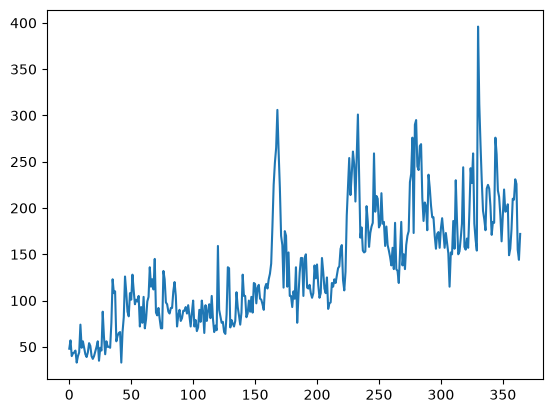

In [17]:
#Plotting graphs 
#Last 365 days main gained subscribers ka plot banao
import numpy as np
import pandas as pd 

fp1=r"C:\Users\Asus\Downloads\kohli_ipl.csv"
fp2=r"C:\Users\Asus\Downloads\subs.csv"
fp3=r"C:\Users\Asus\Downloads\bollywood.csv"

subs=pd.read_csv(fp2).squeeze()
movies=pd.read_csv(fp3,index_col="movie").squeeze()
kohil_runs=pd.read_csv(fp1,index_col="match_no").squeeze()
subs.plot()
print(movies)

<Axes: xlabel='lead'>

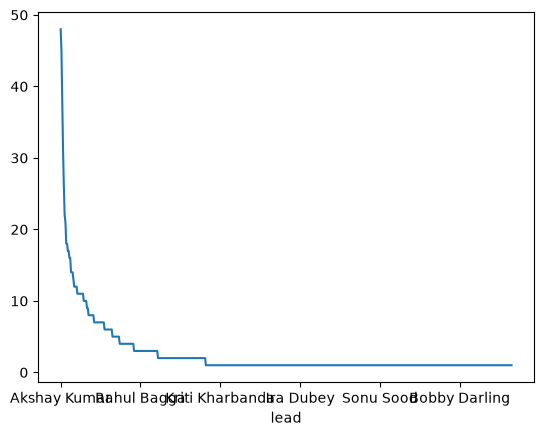

In [18]:
movies.value_counts().plot()

<Axes: xlabel='lead'>

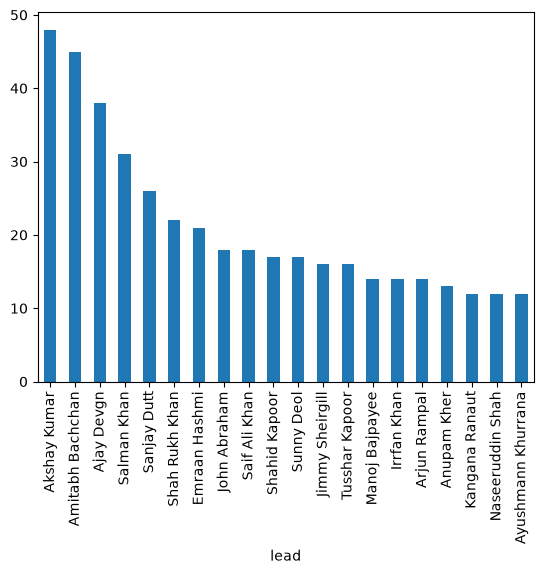

In [77]:
#Suppose top 20 actors ka plot chahiye
movies.value_counts().head(20).plot(kind="bar") #bar chart banega  


Axes(0.22375,0.11;0.5775x0.77)


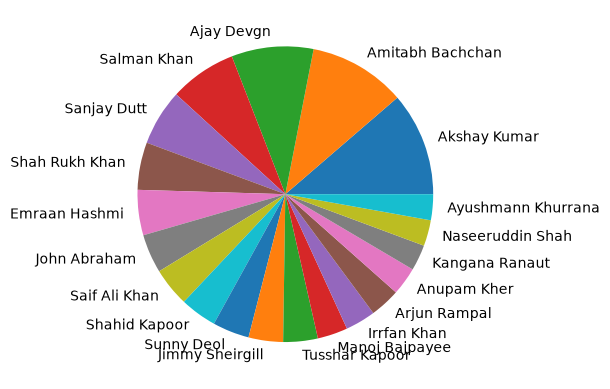

In [19]:
#pie chart 
print(movies.value_counts().head(20).plot(kind="pie"))

Axes(0.125,0.11;0.775x0.77)


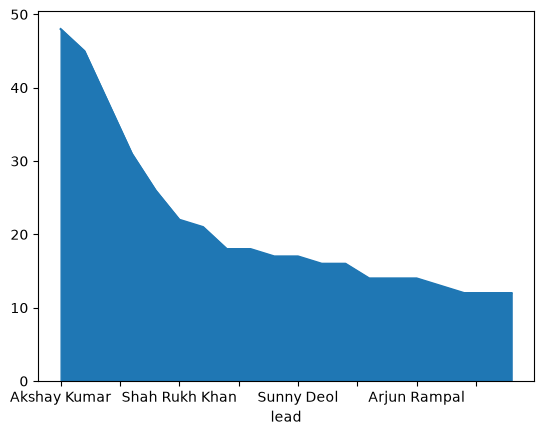

In [20]:
print(movies.value_counts().head(20).plot(kind="area"))

In [23]:
#IMportant series methods 
import numpy as np
import pandas as pd 

fp1=r"C:\Users\Asus\Downloads\kohli_ipl.csv"
fp2=r"C:\Users\Asus\Downloads\subs.csv"
fp3=r"C:\Users\Asus\Downloads\bollywood.csv"

subs=pd.read_csv(fp2).squeeze()
movies=pd.read_csv(fp3,index_col="movie").squeeze()
kohli_runs=pd.read_csv(fp1,index_col="match_no").squeeze()

In [ ]:
#astype changes type oof data 
kohli_runs
import sys 
sys.getsizeof(kohli_runs)/(1024**2)

sys.getsizeof(kohli_runs.astype("int32"))  #yahan jaise ek hi column  tha to koi dikkag nhi jab multiple column rahenge jaise dataframe main toh then apan koo karna padega column secify

1024

In [31]:
#between range ke andar values exist karti hai ki nhi ye batayega
mask=kohli_runs.between(51,99) #can be used as a mask 
kohli_runs[mask]

match_no
34     58
41     71
44     56
45     67
52     70
57     57
68     73
71     51
73     58
74     65
80     57
81     93
82     99
85     56
97     67
99     73
103    51
104    62
110    82
116    75
117    79
119    80
122    52
127    75
129    54
131    54
132    62
134    64
137    55
141    58
144    57
145    92
148    68
152    70
160    84
162    67
175    72
178    90
188    72
197    51
198    53
209    58
213    73
Name: runs, dtype: int64

In [ ]:
#clip ek given range main clip kar deta hai now  subs mhai i want ki in values ko 100 se 200 main clip kardu yni saari value 100 and 200 ke beech hi rhegi

subs.clip(100,200) #subs main jitni value 100 se kam hai wo 100 ho jayengi adn jo 200  se zyada hai wo 200 ho jayegi #aga rkoi value 100 se 200 ke beech hai toh wo change nhi hogi 

0      100
1      100
2      100
3      100
4      100
      ... 
360    200
361    200
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [ ]:
#drop_duplicates kya karta hai a=saare duplicate value drop hoke sirf unique values reh jayengi yni pehle occurence reh jayegi baaki saare duplicates us number ke hath jayenge  
temp = pd.Series([1,1,2,2,3,3,4,4])
temp.drop_duplicates() #default yeh hai ki ksiis number ka pehla occurence rkhke baari sare duplicates us number ke hata  deta hai also isk aparameter hai keep agar keep="last " kiya to kisi number ka last occurence bas chodega baaki saare uda dega 
temp.drop_duplicates(keep="last") 

0    1
2    2
4    3
6    4
dtype: int64

In [ ]:
movies.drop_duplicates() #only 566 unique actors bachenge 

##duplicated batata hai koi value duplicate hui hai ki nhi first occurence ko nhi ginega uske baad aayi to true kar dega can be used as boolean mask 

In [ ]:
#isnull batayega ek series main kitne null hai and boolean series return karega can be used as boolean mask 
temp = pd.Series([1,2,3,np.nan,5,6,np.nan,8,np.nan,10])
temp.size #null value ya missing bhi gin dega 

temp.count() #null uya missing values ko count nhi karega while counting 

temp.isnull() #boolean series return karega jisme true batayega ki yes yahan null hai 
temp[temp.isnull()]


3   NaN
6   NaN
8   NaN
dtype: float64

In [39]:
#misssing /null values ko remove karne ke liye dropna 
temp.dropna()

#agar values nhi hatani hai par unko kisi se replace karna hai then fillna
temp.fillna(67)

0     1.0
1     2.0
2     3.0
3    67.0
4     5.0
5     6.0
6    67.0
7     8.0
8    67.0
9    10.0
dtype: float64

In [49]:
#isin() multiple data ko check karta hai 
#kya kabhi virat  kohli 49 ya 99 pe out hua hai kya ?
kohli_runs[(kohli_runs==49) |   (kohli_runs==99)]

# par sia multiple  data dena ho toh ?
kohli_runs[(kohli_runs.isin([49,99]))]


match_no
82    99
86    49
Name: runs, dtype: int64

In [51]:
#apply help us to apply custom logic to series 

#iwant ki actor ka naam full caps main dikhe plus sirf naam dikhe surname na mile 

movies.apply(lambda x:x.split()[0].upper())

movie
Uri: The Surgical Strike                  VICKY
Battalion 609                             VICKY
The Accidental Prime Minister (film)     ANUPAM
Why Cheat India                          EMRAAN
Evening Shadows                            MONA
                                         ...   
Hum Tumhare Hain Sanam                     SHAH
Aankhen (2002 film)                     AMITABH
Saathiya (film)                           VIVEK
Company (film)                             AJAY
Awara Paagal Deewana                     AKSHAY
Name: lead, Length: 1500, dtype: str

In [52]:
#subs main jis din  average se kam hai   wooh din bad din and jin dinupar hain wo good din

subs.apply(lambda x:"goodday" if x>subs.mean() else  "badday")

0       badday
1       badday
2       badday
3       badday
4       badday
        ...   
360    goodday
361    goodday
362    goodday
363    goodday
364    goodday
Name: Subscribers gained, Length: 365, dtype: str

In [ ]:
#copy and view  difference 

#man;lo  kohli_runs ka series hai and manlo store karna hai first 5 match ka data 

new=kohli_runs.head(5)

print(kohli_runs)
print()
print(new)
# ab koi aake bolta hai tumhara data galat hai kohli ne first match main 1 run banaya tha new main maine change kar diya 

new[1]=1
print(new)
print()
print(kohli_runs)
#ab new main change hoga par kohli_rus originnal series main bhi change hoga ?
# kyu?
# kyunki jab head aur tail karta hoo na tab tum data ka copy(replica) nhi uska view hi utha rahe hote ho original data(reference )

new1=kohli_runs.head(5).copy() #now jo hai kohli ki copy jaayegi original nhi jaayega 